In [16]:
(0.5 * 0.5)**2 * 0.01 * 0.5**2 * 2e-3



3.125e-07

In [2]:
import tidy3d as td
import tidy3d.web as tdweb
import matplotlib.pyplot as plt
import numpy as np
import gdstk
td.config.logging.level = "ERROR"

12:40:36 Mountain Daylight Time WARNING: Using canonical configuration directory
                                at 'C:\Users\Henry\.config\tidy3d'. Found legacy
                                directory at '~/.tidy3d', which will be ignored.
                                Remove it manually or run 'tidy3d config migrate
                                --delete-legacy' to clean up.                   

### Beam waist calculation

MFD of the fiber: 11.84 um

EFL of the lens: 5.95 mm

Free-space BD: 1.86 mm

EFL of the objective: 5.0 mm

Waist of the focused beam: 5 um

In [6]:
(FreqRange[1] - FreqRange[0]) / C_THz

7.137915666666672

<Axes: title={'center': 'cross section at y=0.00 (μm)'}, xlabel='x (μm)', ylabel='z (μm)'>

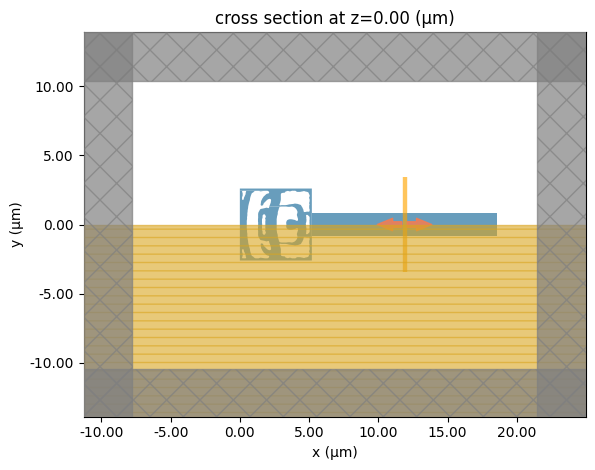

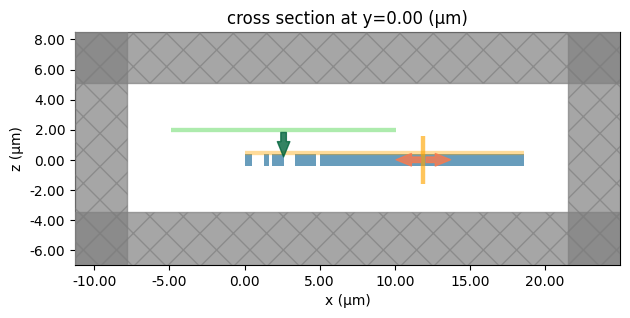

In [3]:
def initFreqParams():
    global Wvl0, WvlRange, Freq0, FreqRange, FreqBandWidth
    if Wvl0 is None and Freq0 is None: 
        raise ValueError('missing Wvl0 or Freq0')
    if WvlRange is None and FreqRange is None:
        raise ValueError('missing WvlRange or FreqRange')

    if Freq0 is None:
        Freq0 = C_c / Wvl0
    elif Wvl0 is None:
        Wvl0 = C_c / Freq0
    else:
        raise ValueError('assigning both Wvl0 and Freq0')

    if FreqRange is None:
        FreqRange = (C_c/WvlRange[1], C_c/WvlRange[0])
    elif WvlRange is None:
        WvlRange = (C_c/FreqRange[1], C_c/FreqRange[0])
    else:
        raise ValueError('assigning both Wvl0 and Freq0')

    FreqBandWidth = (FreqRange[1] - FreqRange[0]) * 3


def initStructs():
    global TDStructs
    lib = gdstk.read_gds(GDS_fp)
    cell = lib.top_level()[0]
    geo = td.Geometry.from_gds(
        gds_cell=cell, 
        slab_bounds=[-0.4,0.4],
        axis=2, 
        gds_layer=0
    )

    TDStructs = [
        td.Structure(
            geometry=geo,
            medium=TDMaterial,
            name='GratingCoupler',
        )
    ]


def initSources():
    global TDSources
    pulse = td.GaussianPulse(
        freq0=Freq0, 
        fwidth=FreqBandWidth,
        amplitude=1,
        phase=0,
    )
    TDSources.append(
        td.GaussianBeam(
            center=BeamCenter,
            size=BeamSize,
            angle_theta=BeamTiltDeg*np.pi/180,
            pol_angle=np.pi/2,
            direction='-',
            waist_radius=BeamWaist,
            waist_distance=-BeamDistance,
            source_time=pulse,
            name='GaussianBeam',
        )
    )
    return TDSources


def initMonitors():
    global TDMonitors

    name = 'output_field'
    TDMonitors.append(
        td.ModeMonitor(
            center=MonOut_Center,
            size=MonOut_Size,
            freqs=MonOut_Freqs.tolist(),
            mode_spec=td.ModeSpec(num_modes=1, target_neff=Tantala_n),
            store_fields_direction='+',
            name=name,
        )
    )

    name = 'cross_section_z'
    TDMonitors.append(
        td.FieldMonitor(
            center=MonCroSecZ_Center,
            size=MonCroSecZ_Size,
            freqs=[Freq0],
            name=name,
        )
    )

    name = 'cross_section_x'
    TDMonitors.append(
        td.FieldMonitor(
            center=MonCroSecX_Center,
            size=MonCroSecX_Size,
            freqs=[Freq0],
            name=name,
        )
    )

    return TDMonitors
    

def initSim():
    global TDSim
    TDBoundarySpec = td.BoundarySpec.all_sides(td.PML())
    TDGridSpec = td.GridSpec.auto(wavelength=Wvl0, min_steps_per_wvl=GridStepsPerWvl) 

    Sim_L = BeamSize[0]/2 + CouplerSize/2 + WaveguideLength + SimPadding_L
    Sim_W = BeamSize[1] + SimPadding_W
    Sim_H = BeamDistance + Thickness + SimPadding_H
    SimCenter_X = (CouplerSize + WaveguideLength - BeamSize[0]/2 + CouplerSize/2) / 2
    SimCenter_Y = 0
    SimCenter_Z = (BeamDistance - Thickness/2) / 2

    TDSim = td.Simulation(
        center=(SimCenter_X, SimCenter_Y, SimCenter_Z),
        size=(Sim_L, Sim_W, Sim_H),
        structures=TDStructs,
        sources=TDSources,
        monitors=TDMonitors,
        grid_spec=TDGridSpec,
        boundary_spec=TDBoundarySpec,
        symmetry=Symmetry,
        run_time=RunTime,
        shutoff=1e-5,
        normalize_index=0
    )
    return TDSim


C_c = td.C_0
C_fs = 1e-15
C_THz = 1e12

Wvl0 = 2.9013670                    # center wavelength in um, length scale of the system
WvlRange = (2.8, 3.0)               # Wavelength range

Freq0 = None                        # center frequency
FreqRange = None                    # frequency range

initFreqParams()

Tantala_n = 2.036
TDMaterial = td.Medium.from_nk(n=Tantala_n, k=0, freq=Freq0)  # 2.0124

#======================================================================
GDS_fp = './grating_coupler.gds'

CouplerSize = 5.2
WaveguideLength = 13.396
WaveguideWidth = 1.7
Thickness = 0.8

ORIGIN_X = CouplerSize/2
ORIGIN_Y = 0
ORIGIN_Z = 0
ORIGIN = (ORIGIN_X, ORIGIN_Y, ORIGIN_Z)
CENTER = ((CouplerSize+WaveguideLength)/2, 0, 0)

TDStructs = []
initStructs()

#======================================================================
BeamWaist = 5
BeamDistance = 2
BeamSize = (3*BeamWaist, 3*BeamWaist, 0)
BeamCenter = (ORIGIN_X, ORIGIN_Y, ORIGIN_Z+BeamDistance)
BeamTiltDeg = 0

TDSources = []
initSources()

#======================================================================
MonIn_Center = (ORIGIN_X, ORIGIN_Y, ORIGIN_Z+3.5)
MonIn_Size = (2*BeamWaist,2*BeamWaist,0)

MonOut_Center = (CouplerSize+WaveguideLength/2, ORIGIN_Y, ORIGIN_Z)
MonOut_Size = (0,WaveguideWidth*4,Thickness*4)
MonOut_Freqs = np.linspace(-FreqBandWidth*2, FreqBandWidth*2, 50) + Freq0

MonCroSecZ_Center = ((CouplerSize+WaveguideLength)/2, ORIGIN_Y, ORIGIN_Z+Thickness/1.9)
MonCroSecZ_Size = (CouplerSize+WaveguideLength, CouplerSize, 0)

MonCroSecX_Center = MonOut_Center
MonCroSecX_Size = MonOut_Size

TDMonitors = []
initMonitors()

#======================================================================
SimPadding_L = Wvl0 * 2
SimPadding_W = Wvl0 * 2
SimPadding_H = Wvl0 * 2

Symmetry = (0, -1, 0)               # parity of field about 3 planes
GridStepsPerWvl = 10                # spatial grid step of simulation in wavelength
RunTime = 1000 * C_fs

TDSim = None
initSim()
TDSim.plot(z=0)
TDSim.plot(y=0)

In [4]:
from datetime import datetime as dt
name = f'Tantala_grating_coupler--{dt.now().strftime("%Y%m%d_%H%M%S")}'
job = tdweb.Job(simulation=TDSim, task_name=name, verbose=False)
est_cost = tdweb.estimate_cost(job.task_id)
print(f'Estimate Cost: {est_cost}')
sim_data = job.run(path=f'data/{name}.hdf5')    
# sim_data = td.SimulationData.from_hdf5('data/tantala-pcc-v1-test.hdf5')

10:07:30 Mountain Daylight Time Estimated FlexCredit cost: 0.025. Minimum cost  
                                depends on task execution details. Use          
                                'web.real_cost(task_id)' to get the billed      
                                FlexCredit cost after a simulation run.

Estimate Cost: 0.025


<Axes: title={'center': 'cross section at x=11.90 (μm)'}, xlabel='y (μm)', ylabel='z (μm)'>

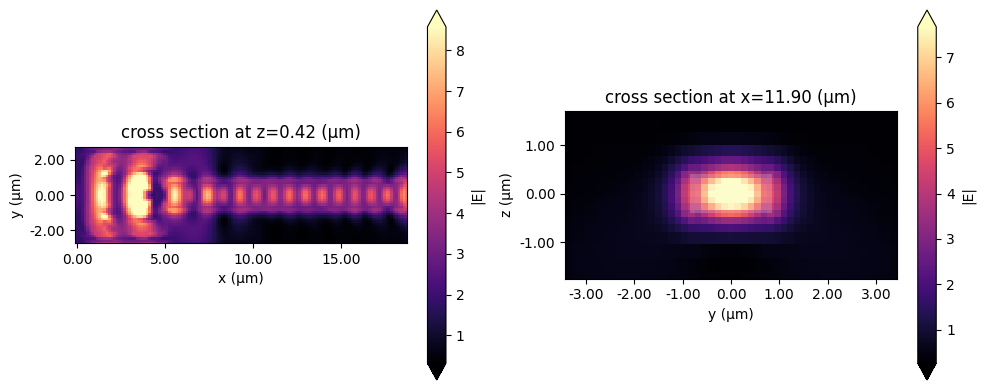

In [48]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), tight_layout=True)
sim_data.plot_field(field_monitor_name='cross_section_z', field_name='E', val='abs', ax=ax[0])
sim_data.plot_field(field_monitor_name='cross_section_x', field_name='E', val='abs', ax=ax[1])

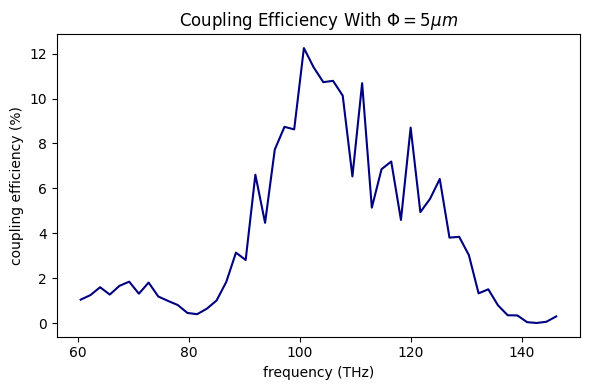

In [ ]:
data = np.abs(sim_data['output_field'].amps.sel(direction='+'))**2
fig, ax = plt.subplots(1, 1, figsize=(6, 4), tight_layout=True)
ax.plot(MonOut_Freqs, data*100, c='navy')
ax.set_xlabel('frequency (THz)')
ax.set_ylabel('coupling efficiency (%)')
ax.set_title(r'Coupling Efficiency With $\Phi=5\mu m$')
pass